# 09 — NDVI MODIS filtrado a píxeles de soja (MNC INTA)

Extrae NDVI promedio por partido y por fecha MODIS, pero solo sobre
píxeles clasificados como soja por el Mapa Nacional de Cultivos del INTA.

**Assets requeridos en GEE** (projects/rinde-soja/assets/):
- mnc-verano-1920 → campaña 2019/20
- mnc-verano-2021 → campaña 2020/21
- mnc-verano-2122 → campaña 2021/22
- mnc-verano-2223 → campaña 2022/23
- mnc-verano-2324 → campaña 2023/24

**Código de soja en MNC verano**: IDVER = 11
(incluye soja de 1ra y 2da, sin discriminar — fuente: informe INTA 2019/2020)

In [1]:
import ee
import pandas as pd
import time

ee.Authenticate()
ee.Initialize(project="rinde-soja")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## Parámetros

In [2]:
SOJA_ID = 11  # Clase "Soja" en MNC verano (Tabla 2 del informe INTA)

# Mapeo campaña → asset (verificado contra Zenodo + informe INTA)
MNC_ASSETS = {
    '2019/20': 'projects/rinde-soja/assets/mnc-verano-1920',
    '2020/21': 'projects/rinde-soja/assets/mnc-verano-2021',
    '2021/22': 'projects/rinde-soja/assets/mnc-verano-2122',
    '2022/23': 'projects/rinde-soja/assets/mnc-verano-2223',
    '2023/24': 'projects/rinde-soja/assets/mnc-verano-2324',
}

def fechas_campana(campana_str):
    """'2019/20' → ('2019-10-01', '2020-04-01')"""
    anio1 = int('20' + campana_str.split('/')[0][-2:])
    anio2 = anio1 + 1
    return f'{anio1}-10-01', f'{anio2}-04-01'

# Partidos de interés
PARTIDOS = ['General Arenales', 'Leandro N. Alem', 'Junin', 'Lincoln', 'General Pinto']

partidos_fc = (ee.FeatureCollection('FAO/GAUL/2015/level2')
    .filter(ee.Filter.eq('ADM0_NAME', 'Argentina'))
    .filter(ee.Filter.eq('ADM1_NAME', 'Buenos Aires'))
    .filter(ee.Filter.inList('ADM2_NAME', PARTIDOS)))

n_partidos = partidos_fc.size().getInfo()
assert n_partidos == 5, f'Se esperaban 5 partidos, se encontraron {n_partidos}'
print(f'✓ {n_partidos} partidos cargados')

C:\Users\agust\AppData\Roaming\Python\Python312\site-packages\ee\deprecation.py:215: DeprecationWarning: 

Attention required for FAO/GAUL/2015/level2! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by FAO/GAUL/2025/level2

Learn more: https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level2

  warnings.warn(warning, category=DeprecationWarning)


✓ 5 partidos cargados


## 1. Verificar cobertura de soja por partido y campaña

Antes de extraer NDVI, veo cuántos píxeles de soja hay en cada
partido para cada campaña.

In [4]:
print('Fracción de soja por partido y campaña (a 30m):')
print('=' * 60)

for campana, asset_id in MNC_ASSETS.items():
    mnc = ee.Image(asset_id).select('b1')
    soja_mask = mnc.eq(SOJA_ID).rename('soja')
    
    stats = soja_mask.reduceRegions(
        collection=partidos_fc,
        reducer=ee.Reducer.mean(),
        scale=30,
        tileScale=4
    ).getInfo()
    
    print('')
    print(f'Campaña {campana}:')
    for feat in stats['features']:
        nombre = feat['properties']['ADM2_NAME']
        frac = feat['properties'].get('mean', 0)
        if frac is not None:
            print(f'  {nombre:25s} → {frac*100:.1f}% soja')
        else:
            print(f'  {nombre:25s} → sin datos')

Fracción de soja por partido y campaña (a 30m):

Campaña 2019/20:
  General Arenales          → 57.3% soja
  General Pinto             → 29.4% soja
  Junin                     → 48.6% soja
  Leandro N. Alem           → 43.4% soja
  Lincoln                   → 22.9% soja

Campaña 2020/21:
  General Arenales          → 61.2% soja
  General Pinto             → 33.7% soja
  Junin                     → 55.2% soja
  Leandro N. Alem           → 53.5% soja
  Lincoln                   → 27.0% soja

Campaña 2021/22:
  General Arenales          → 53.8% soja
  General Pinto             → 25.6% soja
  Junin                     → 48.1% soja
  Leandro N. Alem           → 45.2% soja
  Lincoln                   → 20.0% soja

Campaña 2022/23:
  General Arenales          → 55.4% soja
  General Pinto             → 25.1% soja
  Junin                     → 47.2% soja
  Leandro N. Alem           → 47.8% soja
  Lincoln                   → 19.8% soja

Campaña 2023/24:
  General Arenales          → 56.9% soja
 

## 2. Crear máscara de soja a escala MODIS (250m)

El MNC es a 30m (Landsat). MODIS NDVI es a 250m.
Un píxel MODIS de 250m contiene ~69 píxeles de 30m.

Estrategia:
1. Crear máscara binaria de soja a 30m
2. Calcular fracción de soja dentro de cada píxel MODIS (250m)
3. Mantener solo píxeles MODIS donde la fracción de soja ≥ 50%

In [5]:
def crear_mascara_soja_250m(asset_id, umbral_fraccion=0.5):
    """
    Carga un asset MNC, crea máscara binaria de soja a 30m,
    y la agrega a 250m como fracción. Devuelve máscara binaria
    a 250m donde fracción >= umbral.
    """
    mnc = ee.Image(asset_id).select('b1')
    soja_30m = mnc.eq(SOJA_ID).rename('soja').toFloat()
    
    # Tomar la proyección de una imagen MODIS como referencia
    modis_proj = (ee.ImageCollection('MODIS/061/MOD13Q1')
        .first()
        .select('NDVI')
        .projection())
    
    # Agregar a 250m: mean de la máscara binaria = fracción de soja
    soja_frac_250m = (soja_30m
        .reduceResolution(
            reducer=ee.Reducer.mean(),
            maxPixels=1024
        )
        .reproject(crs=modis_proj, scale=250))
    
    # Máscara final: >=50% del píxel MODIS es soja
    mascara = soja_frac_250m.gte(umbral_fraccion).rename('soja_mask')
    
    return mascara, soja_frac_250m

# Test
mascara_test, frac_test = crear_mascara_soja_250m(MNC_ASSETS['2019/20'])
print('✓ Máscara de soja a 250m creada (test con 2019/20)')

✓ Máscara de soja a 250m creada (test con 2019/20)


## 3. Extraer NDVI filtrado a soja por partido y fecha

Para cada campaña con MNC disponible:
1. Creo máscara de soja a 250m
2. Filtro imágenes MODIS MOD13Q1 en la ventana oct-mar
3. Aplico máscara de soja al NDVI
4. Calculo media por partido

In [7]:
def extraer_ndvi_soja(campana, asset_id, partidos_fc):
    """
    Extrae NDVI medio por partido y fecha MODIS, filtrado a píxeles de soja.
    """
    fecha_inicio, fecha_fin = fechas_campana(campana)
    
    mascara_soja, _ = crear_mascara_soja_250m(asset_id)
    
    modis = (ee.ImageCollection('MODIS/061/MOD13Q1')
        .filterDate(fecha_inicio, fecha_fin)
        .select('NDVI'))
    
    fechas = modis.aggregate_array('system:time_start').getInfo()
    imagenes = modis.toList(modis.size())
    n_imgs = len(fechas)
    
    resultados = []
    
    for i in range(n_imgs):
        img = ee.Image(imagenes.get(i))
        fecha_ms = fechas[i]
        fecha_str = pd.Timestamp(fecha_ms, unit='ms').strftime('%Y-%m-%d')
        
        ndvi_soja = (img
            .multiply(0.0001)
            .updateMask(mascara_soja))
        
        stats = ndvi_soja.reduceRegions(
            collection=partidos_fc,
            reducer=ee.Reducer.mean().combine(
                ee.Reducer.count(), sharedInputs=True
            ),
            scale=250,
            tileScale=4
        ).getInfo()
        
        for feat in stats['features']:
            nombre = feat['properties']['ADM2_NAME']
            ndvi_mean = feat['properties'].get('mean')
            n_pixels = feat['properties'].get('count', 0)
            
            resultados.append({
                'campana': campana,
                'partido': nombre,
                'fecha': fecha_str,
                'ndvi_soja_mean': ndvi_mean,
                'n_pixels_soja': n_pixels
            })
        
        print(f'  {fecha_str} ✓ ({i+1}/{n_imgs})')
        time.sleep(0.5)
    
    return resultados

In [8]:
todos_resultados = []

for campana, asset_id in MNC_ASSETS.items():
    print('')
    print('=' * 50)
    print(f'Campaña {campana}')
    print('=' * 50)
    
    resultados = extraer_ndvi_soja(campana, asset_id, partidos_fc)
    todos_resultados.extend(resultados)
    print(f'→ {len(resultados)} registros extraídos')

df_ndvi_soja = pd.DataFrame(todos_resultados)
df_ndvi_soja['fecha'] = pd.to_datetime(df_ndvi_soja['fecha'])

print('')
print(f'✓ Total: {len(df_ndvi_soja)} registros')
print(f'  Campañas: {df_ndvi_soja["campana"].nunique()}')
print(f'  Partidos: {df_ndvi_soja["partido"].nunique()}')
df_ndvi_soja.head(10)


Campaña 2019/20
  2019-10-16 ✓ (1/11)
  2019-11-01 ✓ (2/11)
  2019-11-17 ✓ (3/11)
  2019-12-03 ✓ (4/11)
  2019-12-19 ✓ (5/11)
  2020-01-01 ✓ (6/11)
  2020-01-17 ✓ (7/11)
  2020-02-02 ✓ (8/11)
  2020-02-18 ✓ (9/11)
  2020-03-05 ✓ (10/11)
  2020-03-21 ✓ (11/11)
→ 55 registros extraídos

Campaña 2020/21
  2020-10-15 ✓ (1/11)
  2020-10-31 ✓ (2/11)
  2020-11-16 ✓ (3/11)
  2020-12-02 ✓ (4/11)
  2020-12-18 ✓ (5/11)
  2021-01-01 ✓ (6/11)
  2021-01-17 ✓ (7/11)
  2021-02-02 ✓ (8/11)
  2021-02-18 ✓ (9/11)
  2021-03-06 ✓ (10/11)
  2021-03-22 ✓ (11/11)
→ 55 registros extraídos

Campaña 2021/22
  2021-10-16 ✓ (1/11)
  2021-11-01 ✓ (2/11)
  2021-11-17 ✓ (3/11)
  2021-12-03 ✓ (4/11)
  2021-12-19 ✓ (5/11)
  2022-01-01 ✓ (6/11)
  2022-01-17 ✓ (7/11)
  2022-02-02 ✓ (8/11)
  2022-02-18 ✓ (9/11)
  2022-03-06 ✓ (10/11)
  2022-03-22 ✓ (11/11)
→ 55 registros extraídos

Campaña 2022/23
  2022-10-16 ✓ (1/11)
  2022-11-01 ✓ (2/11)
  2022-11-17 ✓ (3/11)
  2022-12-03 ✓ (4/11)
  2022-12-19 ✓ (5/11)
  2023-01-01 ✓ 

,campana,partido,fecha,ndvi_soja_mean,n_pixels_soja
0,2019/20,General Arenales,2019-10-16,0.528504,13868
1,2019/20,General Pinto,2019-10-16,0.584130,11310
2,2019/20,Junin,2019-10-16,0.530634,16857
3,2019/20,Leandro N. Alem,2019-10-16,0.526198,10938
4,2019/20,Lincoln,2019-10-16,0.527783,20074
5,2019/20,General Arenales,2019-11-01,0.506775,13860
6,2019/20,General Pinto,2019-11-01,0.563284,11308
7,2019/20,Junin,2019-11-01,0.518982,16849
8,2019/20,Leandro N. Alem,2019-11-01,0.507834,10930
9,2019/20,Lincoln,2019-11-01,0.522620,20071


In [11]:
import os
output_path = r'C:\Users\agust\Documents\rinde-soja\data\raw\ndvi\ndvi_modis_soja_filtrado_zona_coop.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_ndvi_soja.to_csv(output_path, index=False)
print(f'✓ Guardado en {output_path}')

✓ Guardado en C:\Users\agust\Documents\rinde-soja\data\raw\ndvi\ndvi_modis_soja_filtrado_zona_coop.csv


## 4. Comparar NDVI filtrado vs original

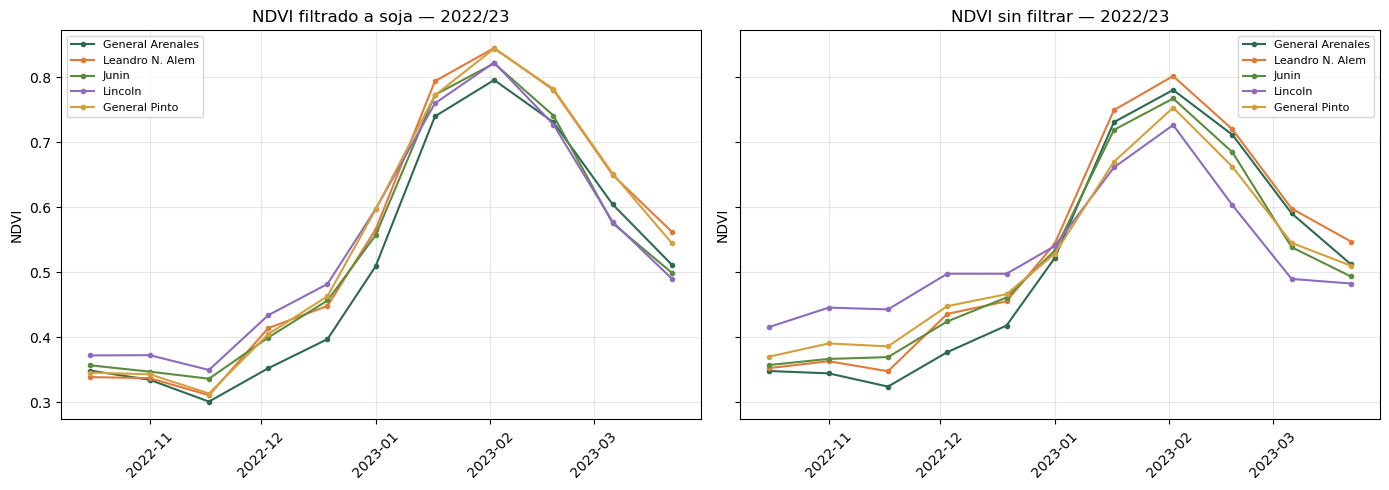

✓ Figura guardada


In [18]:
import matplotlib.pyplot as plt

# Cargar NDVI original (sin filtro de cultivo)
df_original = pd.read_csv(r'C:\Users\agust\Documents\rinde-soja\data\raw\ndvi\ndvi_modis_zona_coop_2000_2025.csv')
df_original['fecha'] = pd.to_datetime(df_original['fecha'])
df_original['partido'] = df_original['partido'].str.replace('Junín', 'Junin')

COLORES = {
    'General Arenales': '#2D6A4F',
    'Leandro N. Alem': '#E07A3A',
    'Junin': '#5B8C3E',
    'Lincoln': '#8E6BBF',
    'General Pinto': '#D4A03C'
}

campana_ejemplo = '2022/23'
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for partido in PARTIDOS:
    color = COLORES[partido]
    
    # Filtrado (soja)
    mask_f = ((df_ndvi_soja['campana'] == campana_ejemplo) & 
              (df_ndvi_soja['partido'] == partido))
    sub_f = df_ndvi_soja[mask_f].sort_values('fecha')
    
    axes[0].plot(sub_f['fecha'], sub_f['ndvi_soja_mean'], 
                 color=color, marker='o', markersize=3, label=partido)
    
    # Original — mismas fechas
    fecha_ini, fecha_fin = fechas_campana(campana_ejemplo)
    mask_o = ((df_original['partido'] == partido) & 
              (df_original['fecha'] >= fecha_ini) & 
              (df_original['fecha'] < fecha_fin))
    sub_o = df_original[mask_o].sort_values('fecha')
    
    axes[1].plot(sub_o['fecha'], sub_o['ndvi'], 
                 color=color, marker='o', markersize=3, label=partido)

axes[0].set_title(f'NDVI filtrado a soja — {campana_ejemplo}')
axes[1].set_title(f'NDVI sin filtrar — {campana_ejemplo}')
for ax in axes:
    ax.set_ylabel('NDVI')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r'C:\Users\agust\Documents\rinde-soja\outputs\comparacion_ndvi_soja_vs_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura guardada')

## 5. Resumen: diferencia filtrado vs original

In [19]:
df_comp = df_ndvi_soja.merge(
    df_original[['partido', 'fecha', 'ndvi']],
    on=['partido', 'fecha'],
    how='inner'
)
df_comp['diff'] = df_comp['ndvi_soja_mean'] - df_comp['ndvi']

print('Diferencia NDVI (filtrado soja - original) por partido:')
print(df_comp.groupby('partido')['diff'].agg(['mean', 'std', 'min', 'max']).round(4))
print()
print('Diferencia promedio general:', df_comp['diff'].mean().round(4))

Diferencia NDVI (filtrado soja - original) por partido:
                    mean     std     min     max
partido                                         
General Arenales  0.0138  0.0478 -0.0716  0.0938
General Pinto     0.0417  0.0813 -0.1293  0.1797
Junin             0.0307  0.0525 -0.0710  0.1237
Leandro N. Alem   0.0169  0.0555 -0.0864  0.1115
Lincoln           0.0219  0.0775 -0.1163  0.1468

Diferencia promedio general: 0.025
